# OpenFAST session 1. 

Welcome to this tutorial on how to use OpenFAST to run a model of the SWRT wind turbine. OpenFAST is an open-source wind turbine simulation tool that allows engineers and researchers to analyze the performance and behavior of wind turbines.

In this tutorial, we will guide you through the process of setting up and running the SWRT wind turbine model using OpenFAST. You will learn how to configure the model, specify the input parameters, and analyze the simulation results.

By the end of this tutorial, you will have a solid understanding of how to use OpenFAST for wind turbine analysis and be able to apply this knowledge to your own projects.

To access the OpenFAST GitHub repository, you can click [here](https://github.com/OpenFAST/openfast). In the repository, you will find various scripts and models that can be used for wind turbine simulation and analysis. These resources can be a valuable reference for understanding the inner workings of OpenFAST and for customizing and extending its functionality to suit your specific needs.

By exploring the OpenFAST GitHub repository, you can gain insights into the implementation details of the simulation tool, access example models, and find documentation that will help you navigate through the various features and capabilities of OpenFAST.

Let's get started with using OpenFAST for wind turbine analysis and simulation!

Let's get started!

## Loading libraries

The first step is to load python libraries that we are going to use through the tutorial. Because they require specific installation, we have copied the library from OpenFAST GitHub and we are importing them locally. 

In [3]:
import sys 
import os 
script_dir = os.getcwd()
sys.path.append(script_dir + "/../openfast_toolbox_local")
from openfast_toolbox.io import FASTInputFile, TurbSimFile, FASTOutputFile   
from openfast_toolbox.case_generation import runner 

import matplotlib.pyplot as plt 




## Input files 

Any OpenFAST model starts with a main file for the glue-code driver. This file has the .fst extension. You can open it by hand, or using the python toolbox. Let's navigate this file. 

#### _Question 1 . For each of this parameter of the .fst file, explain what choice was made._  (Hint : you can use the [documentation](https://openfast.readthedocs.io/en/main/))

**Echo = True**

**TMax = 70**

**CompElast = 1** 

**SumPrint = True** 

**OutFileFmt = 1** 

*Answer 1* : [TO COMPLETE]

You can access each parameter value opening the .fst file using any text editor, or you can use the openfast-toolbox as well:

In [4]:
fstFileLocation = r"SWRT_01/SWRT_01.fst"
fstFile = FASTInputFile(fstFileLocation)
for key in ['Echo','TMax','CompServo'] : 
    print(f"{key} has the value {fstFile[key]}")


Echo has the value True
TMax has the value 70
CompServo has the value 0


The glue-code is the interface between each module. It does not hold any physical variable, therefore the variables are stored in the modules. To setup a simulation, parameter files are needed for each modules. The glue code will reference this parameter files so it knows where each module has to look for its variables. 

The path to each module parameter file (.dat files) is referenced in the .fst file. The path is always given relative to the folder where the .fst lies. The only module that is compulsory to start a simulation is the Elastodyn module. 

In [5]:
print(f"The path to the Elastodyn file is {fstFile['EDFile']}")

EDFile = FASTInputFile('SWRT_01/Elastodyn/SWRT_ED.dat')

The path to the Elastodyn file is "Elastodyn/SWRT_ED.dat"


#### _Question 2 . For each of this parameter of the Elastodyn .dat file, explain what choice was made._

**FlapDOF1 = True**

**PtfmSgDOF = False** 

**RotSpeed = 188**

**HubRad = 0.303**

**TipRad = 2.9**

**GBRatio = 1** 






_Answer 2_ : [TO COMPLETE]

Additionnaly, the Elastodyn file is used to specify what type of outputs we want printed in the results .out file. There are many (many) available outputs and they are referenced in the the excel table outlistParameters.xlsx.  

#### _Question 3: Using the excel table OutListParameters.xlsx, explain what variable should be added to the output list of the Elastodyn file to retrieve :_

**the Blade 1 pitching angle** 

**the rotor power** 

**the tower top pitch bending moment (My)** 

*Answer 3* : [TO COMPLETE]

# Running a simulation

Once we are satisfied with the input files we set, we can finally launch the simulation. This can be done using the python toolbox but this will be addressed later. For now, we will launch it manually using a command window. 

 1. Open a command window in the folder where your .fst lies 
 2. Retrieve the path to your the openfast executable 
 3. Launch openfast using the following line "**[path_to_executable] [fstfilename]**"

the command line here is :
<code>
    ..\executables\openfast_x64.exe SWRT_01.fst
</code>

Note : this tutorial was set for OpenFAST 3.5.xx

# Process the output

If openfast terminated normally, the folder where the .fst file lies should now have some new files appeared. The various files you can find are : 

* _.ech_ files are for debugging purpose, they save the output and messages from the program 
* _.sum_ files are summeray files, sometimes they can hold precious informations about the system 
* _.out_ files are time series files, you can read them using several methods, here we will use the openfast-toolbox. 

#### _Question 4: In the summary files, find : :_

1. the height of the tower 
2. the weight of the blades
3. the number of active degrees of freedom in the simulation


_Answer 4_ : [TO COMPLETE]

Now we can display the output of the simulation using the toolbox. 

In [7]:
outFilePath = "./SWRT_01/SWRT_01.out"
outFile = FASTOutputFile(outFilePath).toDataFrame()
availableChannels = outFile.keys()
print(availableChannels)

Index(['Time_[s]', 'TwrClrnc1_[m]', 'TwrClrnc2_[m]', 'TwrClrnc3_[m]',
       'LSSTipV_[rpm]', 'NacYaw_[deg]', 'RootFzb3_[kN]', 'RootMEdg3_[kN-m]',
       'RootMFlp3_[kN-m]', 'LSShftFxs_[kN]', 'LSShftMxs_[kN-m]',
       'YawBrFzn_[kN]'],
      dtype='object')


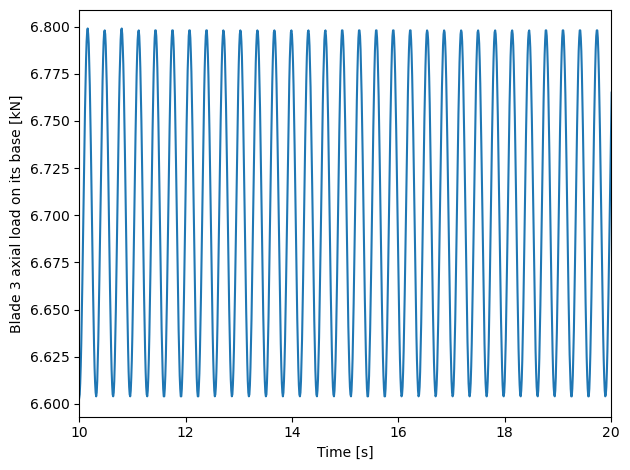

In [8]:
fig, axs = plt.subplots(1,1)
ax = axs
ax.plot(outFile['Time_[s]'],outFile['RootFzb3_[kN]'])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Blade 3 axial load on its base [kN]')
ax.set_xlim([10,20])
plt.tight_layout()
plt.show()

#### _Question 5 : Interpret this result, what are the two main components of this load ?_ 

_Answer 5_ : [TO COMPLETE] 

# Problem 
You have designed a turbine just like the SWRT for a client. Your intention was to have a rotor shaft tilt angle of 8°, but dew to manufacturing issues your client asks you if it is possible to set it to 2° instead, and proposes to set a pre-cone angle to the blades of 3° to compensate. Using OpenFAST, check if the blades are going to be closer or further to hitting the tower. 

You are not taking into account the wind or any other effect. 


_Answer to the problem:_ 